In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch_geometric
import matplotlib.pyplot as plt
from scipy.stats import linregress
from torch.utils.data import TensorDataset, DataLoader
import math
from sklearn.preprocessing import StandardScaler


A549 = torch.load('/content/drive/MyDrive/Master/Deep Learning/Trabajo Final/data/data_backward_A549.pt', weights_only=False )
HT29 =  torch.load('/content/drive/MyDrive/Master/Deep Learning/Trabajo Final/data/data_backward_HT29.pt' , weights_only=False)
PC3 =  torch.load('/content/drive/MyDrive/Master/Deep Learning/Trabajo Final/data/data_backward_PC3.pt', weights_only=False )

In [ ]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit
import numpy as np
from scipy.stats import pearsonr

def prepare_splits(dataset, val_size, test_size, splitting_scheme, N_folds=1, seed=42):

    if splitting_scheme == "random":
# Random classic split
       all_idx = list(range(len(dataset)))
       trainval_idx, test_idx = train_test_split(all_idx, test_size=test_size, random_state=seed)
       rel_val_size = val_size / (1.0 - test_size)
       train_idx_dict, val_idx_dict = {}, {}
       for fold in range(N_folds):
           train_idx, val_idx = train_test_split(trainval_idx, test_size=rel_val_size,
           random_state=seed + fold)
           train_idx_dict[fold] = list(train_idx)
           val_idx_dict[fold] = list(val_idx)
       return train_idx_dict, val_idx_dict, list(test_idx)
    elif splitting_scheme == "unseen_interventions":
# Train/Val/Test has unique interventions
# Group by intervention
        group_keys = [tuple(np.nonzero(item['intervention'].cpu().numpy())[0].tolist()) for item in
                 dataset]
        unique_map = {k: i for i, k in enumerate(dict.fromkeys(group_keys))}
        groups_int = np.array([unique_map[k] for k in group_keys], dtype=int)
        all_idx = list(range(len(dataset)))
        X = np.arange(len(all_idx))
# test
        gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        _, test_idx = next(gss_test.split(X=X, groups=groups_int))
        test_idx = list(test_idx)
        pool_index = [i for i in all_idx if i not in set(test_idx)]
        rel_val_size = val_size / (1.0 - test_size)
        pool_groups = groups_int[pool_index]
        X_pool = np.arange(len(pool_index))
#Train and validation
        train_idx_dict, val_idx_dict = {}, {}
        for fold in range(N_folds):
            gss_val = GroupShuffleSplit(n_splits=1, test_size=rel_val_size, random_state=seed
                  + fold)
            train_rel, val_rel = next(gss_val.split(X=X_pool, groups=pool_groups))
            train_idx = [pool_index[i] for i in train_rel]
            val_idx = [pool_index[i] for i in val_rel]
            train_idx_dict[fold] = list(train_idx)
            val_idx_dict[fold] = list(val_idx)
        return train_idx_dict, val_idx_dict, list(test_idx)
    else:
        raise ValueError("splitting_scheme must be 'random' or 'unseen_interventions'")

def samplewise_r2(y_true, y_pred):
   y_true = np.asarray(y_true)
   y_pred = np.asarray(y_pred)
   n_samples = y_true.shape[0]
   r2 = np.empty(n_samples, dtype=float)
   for i in range(n_samples):
      r2[i] = pearsonr(y_true[i], y_pred[i])[0] ** 2
   return r2

def gene_var_score(y_true, y_pred, eps=1e-12):

   y_true = np.asarray(y_true)
   y_pred = np.asarray(y_pred)
   var_true = np.var(y_true, axis=0)
   var_pred = np.var(y_pred, axis=0)
   ratio = (var_pred + eps) / (var_true + eps)
   score = np.exp(-np.abs(np.log(ratio)))
   return score


In [ ]:
class AutoencoderSC(nn.Module):
    def __init__(self, n_genes):
        super().__init__()
        # Encoder: Comprime la información a espacio latente
        self.encoder = nn.Sequential(
            nn.Linear(n_genes, 1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.1),


            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),

            nn.Linear(512,128)
        )
        # Decoder: Reconstruye los genes
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),

            nn.Linear(512,1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.1),

            nn.Linear(1024, n_genes)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_pred = self.decoder(z)
        return x_pred, z

# Task 3 : Diferentes Splits y otras 2 lineas celulares

Los datos anteriores son usando el split unseen_interventions de la funcion prepare splits. Ahora realizaremos lo mismo pero usando el split random y tambien vamos a entrenar el autoencoder con los datos de todas las lineas celulares para usar el mismo y que todo viva en el mismo espacio latente.

In [ ]:
# Definimos un mapeo para las líneas celulares (asi el modelo de diff podra enteder patrones especificos de cada modelo)
# PC3: 0, A549: 1, HT29: 2 y el 3 sera para desconocido
for sample in PC3:
    sample['cell_line'] = torch.tensor([0], dtype=torch.long)
for sample in HT29:
    sample['cell_line'] = torch.tensor([1], dtype=torch.long)
for sample in A549:
    sample['cell_line'] = torch.tensor([2], dtype=torch.long)

# Al añadir esto tendremos que modeificar un poco el modelo de difusion para añadir
# un embedding del cell line

In [ ]:
dataset_total = PC3 + HT29 + A549

# primero separamos el train test
train_idx_dict, val_idx_dict, test_idx = prepare_splits(dataset = dataset_total , val_size= 0.1 , test_size=0.1 , splitting_scheme = 'unseen_interventions')

# nos quedamos con el primer fold
train_idx = train_idx_dict[0]
val_idx = val_idx_dict[0]

# Seleccionamos los mejores genes (Como he explicado antes)
all_interventions = torch.stack([d.intervention for d in dataset_total]).sum(dim=0)
idx_perturbed = torch.where(all_interventions > 0)[0].numpy()

diffs = []
for i in train_idx:
    d = dataset_total[i]
    diffs.append(torch.abs(d.treated - d.diseased))
mean_diffs = torch.stack(diffs).mean(dim=0)
idx_degs = torch.topk(mean_diffs, k=1000).indices.numpy()

final_gene_indices = np.unique(np.concatenate([idx_perturbed, idx_degs]))
print(f"Tenemos {len(final_gene_indices)} genes selecionados")

diseased_tensor = torch.stack([d.diseased for d in dataset_total])
intervention_tensor = torch.stack([d.intervention for d in dataset_total])
treated_tensor = torch.stack([d.treated for d in dataset_total])

# nos quedamos con los genes selecionados en los 3 tensores
diseased_matrix = diseased_tensor[:, final_gene_indices].numpy()
treated_matrix = treated_tensor[:, final_gene_indices].numpy()
intervention_matrix = intervention_tensor[:, final_gene_indices].numpy()


print(diseased_matrix.shape)
print(treated_matrix.shape)
print(intervention_matrix.shape)

Tenemos 4206 genes selecionados
(66009, 4206)
(66009, 4206)
(66009, 4206)


In [ ]:
# Nuevo autoencoder
ae_train = torch.tensor(np.vstack([diseased_matrix[train_idx], treated_matrix[train_idx]]),dtype= torch.float32)
ae_val = torch.tensor(np.vstack([diseased_matrix[val_idx], treated_matrix[val_idx]]),dtype= torch.float32)
ae_test = torch.tensor(np.vstack([diseased_matrix[test_idx], treated_matrix[test_idx]]),dtype= torch.float32)

dataset_ae_train = TensorDataset(ae_train, ae_train)
dataset_ae_val = TensorDataset(ae_val, ae_val)
dataset_ae_test = TensorDataset(ae_test, ae_test)

dataloader_ae_train = DataLoader(dataset_ae_train, batch_size=128, shuffle=True)
dataloader_ae_val = DataLoader(dataset_ae_val, batch_size=128, shuffle=False)
dataloader_ae_test = DataLoader(dataset_ae_test, batch_size=128, shuffle=False)

print(f"Muestras para entrenar el AE: {len(dataset_ae_train)}")
print(f"Batches por epoch en train: {len(dataloader_ae_train)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = AutoencoderSC(n_genes= len(final_gene_indices) ).to(device)
optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=1e-4)
loss_fn_ae = nn.SmoothL1Loss()

epochs_ae = 150
'''
for epoch in range(epochs_ae):
    # ENTRENAMIENTO
    autoencoder.train()
    loss_total = 0
    for x_batch, _ in dataloader_ae_train:
        x_batch = x_batch.to(device)

        x_pred, z = autoencoder(x_batch)
        loss = loss_fn_ae(x_pred, x_batch)

        optimizer_ae.zero_grad()
        loss.backward()
        optimizer_ae.step()

        loss_total += loss.item()

    # VALIDACIÓN
    autoencoder.eval()
    val_loss_total = 0
    with torch.no_grad():
        for x_val, _ in dataloader_ae_val:
            x_val = x_val.to(device)

            x_pred_val, _ = autoencoder(x_val)
            val_loss = loss_fn_ae(x_pred_val, x_val)

            val_loss_total += val_loss.item()


    if (epoch + 1) % 10 == 0:
        train_loss_avg = loss_total / len(dataloader_ae_train)
        val_loss_avg = val_loss_total / len(dataloader_ae_val)
        print(f"AE Epoch [{epoch+1}/{epochs_ae}] | Train Loss: {train_loss_avg:.4f} | Validation Loss: {val_loss_avg:.4f}")'''

Muestras para entrenar el AE: 106448
Batches por epoch en train: 832


'\nfor epoch in range(epochs_ae):\n    # ENTRENAMIENTO\n    autoencoder.train()\n    loss_total = 0\n    for x_batch, _ in dataloader_ae_train:\n        x_batch = x_batch.to(device)\n\n        x_pred, z = autoencoder(x_batch)\n        loss = loss_fn_ae(x_pred, x_batch)\n\n        optimizer_ae.zero_grad()\n        loss.backward()\n        optimizer_ae.step()\n\n        loss_total += loss.item()\n\n    # VALIDACIÓN\n    autoencoder.eval()\n    val_loss_total = 0\n    with torch.no_grad():\n        for x_val, _ in dataloader_ae_val:\n            x_val = x_val.to(device)\n\n            x_pred_val, _ = autoencoder(x_val)\n            val_loss = loss_fn_ae(x_pred_val, x_val)\n\n            val_loss_total += val_loss.item()\n\n\n    if (epoch + 1) % 10 == 0:\n        train_loss_avg = loss_total / len(dataloader_ae_train)\n        val_loss_avg = val_loss_total / len(dataloader_ae_val)\n        print(f"AE Epoch [{epoch+1}/{epochs_ae}] | Train Loss: {train_loss_avg:.4f} | Validation Loss: {val_l

In [ ]:
#torch.save(autoencoder.state_dict(), '/content/drive/MyDrive/Master/Deep Learning/Trabajo Final/modelos/autoencoder_definitivo_pesos.pth')

In [ ]:
# Le cargamos los pesos del Drive
ruta_guardado = '/content/drive/MyDrive/Master/Deep Learning/Trabajo Final/modelos/autoencoder_definitivo_pesos.pth'
autoencoder.load_state_dict(torch.load(ruta_guardado))

# Lo ponemos en modo evaluación y lo congelamos
autoencoder.eval()
for param in autoencoder.parameters():
    param.requires_grad = False # Congela los pesos,

print("Autoencoder definitivo cargado y listo")

Autoencoder definitivo cargado y listo


# Difusion Model


In [ ]:
import math
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ResidualBlock(nn.Module):
    def __init__(self, dim, cond_dim):
        super().__init__()
        self.linear1 = nn.Linear(dim, dim)
        self.act1 = nn.SiLU()
        self.linear2 = nn.Linear(dim, dim)
        self.act2 = nn.SiLU()

        # Capa para inyectar el contexto
        self.cond_proj = nn.Linear(cond_dim, dim)

    def forward(self, x, cond):
        # El contexto modifica el estado oculto de la célula
        h = self.linear1(x) + self.cond_proj(cond)
        h = self.act1(h)
        h = self.linear2(h)
        return h + x # Conexión residual (suma la entrada original)

class PerturbationDiffusion_v2(nn.Module):
    def __init__(self, latent_dim=128, diseased_dim=128, intervention_dim = len(final_gene_indices), hidden_dim=512, cond_dim=256, num_cell_lines=3):
      super().__init__()
      self.latent_dim = latent_dim
       # embedding de la t
      self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(cond_dim),
            nn.Linear(cond_dim, cond_dim),
            nn.SiLU()
        )
      # Procesador del estado basal 'diseased'
      self.diseased_mlp = nn.Sequential(
            nn.Linear(diseased_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim)
        )
      # Procesador de la intervención
      self.intervention_mlp = nn.Sequential(
            nn.Linear(intervention_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim)
        )
      # Embedding para la linea celular
      self.cell_line_emb = nn.Embedding(num_cell_lines, cond_dim)

      # Capa de entrada (recibe el latente ruidoso de la célula treated)
      self.init_lin = nn.Linear(latent_dim, hidden_dim)

      # Bloques residuales
      self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, cond_dim),
            ResidualBlock(hidden_dim, cond_dim),
            ResidualBlock(hidden_dim, cond_dim),
            ResidualBlock(hidden_dim, cond_dim)
        ])
      # Capa de salida (predice el ruido añadido)
      self.out_lin = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x_t, t, diseased_state, intervention_vector, cell_line_idx):
        # Calculamos los 4 embeddings
        t_emb = self.time_mlp(t)
        dis_emb = self.diseased_mlp(diseased_state)
        int_emb = self.intervention_mlp(intervention_vector)
        line_emb = self.cell_line_emb(cell_line_idx)

        # Sumamos
        # "Nivel de ruido T" + "Estado Genético Previo" + "Gen Apagado" + 'Cell line
        context = t_emb + dis_emb + int_emb + line_emb

        # Pasamos el vector (con ruido) por la red de bloques residuales
        x = self.init_lin(x_t)

        for block in self.blocks:
            x = block(x, context) # Inyectamos el contexto biológico en cada capa

        # Predecimos el ruido para limpiar
        ruido_predicho = self.out_lin(x)
        return ruido_predicho

In [ ]:
def train_step_perturbation(model, z_0_treated, diseased_state, intervention_vector, cell_line_idx,optimizer):
# z_0_treated: El estado FINAL de la célula (comprimido a latente por el Autoencoder) objetivo
# diseased_state: El estado INICIAL de la célula (comprimido a latente)
# intervention_vector: Los genes apagados (unos y ceros, 4216 dims)
# cell_line_idx: El índice de la línea celular (0, 1 o 2)
    model.train()
    optimizer.zero_grad()

    device = z_0_treated.device
    batch_size = z_0_treated.shape[0]

    # Tiempo aleatorio para cada célula del batch (t entre 0 y 1)
    t = torch.rand(batch_size, device=device).unsqueeze(1)

    # Ruido puro (Epsilon)
    epsilon = torch.randn_like(z_0_treated).to(device)

    # COSINE SCHEDULE
    theta = t * (math.pi / 2)
    alpha_t = torch.cos(theta) # Proporción de señal original
    sigma_t = torch.sin(theta) # Proporción de ruido

    # Ensuciaremos el estado FINAL (treated). El modelo tendrá que aprender a limpiarlo.
    z_t = alpha_t * z_0_treated + sigma_t * epsilon
    pred_noise = model(z_t, t.squeeze(1), diseased_state, intervention_vector,cell_line_idx)
    loss = nn.MSELoss()(pred_noise, epsilon)
    loss.backward()
    optimizer.step()

    return loss.item()

In [ ]:
# cogemos las lineas celulares de los genes seleccionados
cell_train = torch.tensor([dataset_total[i]['cell_line'].item() for i in train_idx], dtype=torch.long).to(device)
cell_val = torch.tensor([dataset_total[i]['cell_line'].item() for i in val_idx], dtype=torch.long).to(device)
cell_test = torch.tensor([dataset_total[i]['cell_line'].item() for i in test_idx], dtype=torch.long).to(device)

# nos quedamos con los genes seleccionados y hacemos nuestro X e Y (tensores)
# Train
x_dis_train = torch.tensor(diseased_matrix[train_idx], dtype=torch.float32).to(device)
y_tre_train = torch.tensor(treated_matrix[train_idx], dtype=torch.float32).to(device)
int_train = torch.tensor(intervention_matrix[train_idx], dtype=torch.float32).to(device)
# Val
x_dis_val = torch.tensor(diseased_matrix[val_idx], dtype=torch.float32).to(device)
y_tre_val = torch.tensor(treated_matrix[val_idx], dtype=torch.float32).to(device)
int_val = torch.tensor(intervention_matrix[val_idx], dtype=torch.float32).to(device)
# Test
x_dis_test = torch.tensor(diseased_matrix[test_idx], dtype=torch.float32).to(device)
y_tre_test = torch.tensor(treated_matrix[test_idx], dtype=torch.float32).to(device)
int_test = torch.tensor(intervention_matrix[test_idx], dtype=torch.float32).to(device)

In [ ]:
# Comprimimos con el Autoencoder
autoencoder.eval()
with torch.no_grad():
    # Bajamos a CPU para el Scaler
    z_dis_train = autoencoder.encoder(x_dis_train).cpu().numpy()
    z_tre_train = autoencoder.encoder(y_tre_train).cpu().numpy()

    z_dis_val = autoencoder.encoder(x_dis_val).cpu().numpy()
    z_tre_val = autoencoder.encoder(y_tre_val).cpu().numpy()

    z_dis_test = autoencoder.encoder(x_dis_test).cpu().numpy()
    z_tre_test = autoencoder.encoder(y_tre_test).cpu().numpy()

# Scaler entrenado SOLO con los datos de train
scaler_latente = StandardScaler()
z_train_combinado = np.vstack([z_dis_train, z_tre_train])
scaler_latente.fit(z_train_combinado)

# Transformamos todos los datos
z_dis_train_scaled = scaler_latente.transform(z_dis_train)
z_tre_train_scaled = scaler_latente.transform(z_tre_train)

z_dis_val_scaled = scaler_latente.transform(z_dis_val)
z_tre_val_scaled = scaler_latente.transform(z_tre_val)

z_dis_test_scaled = scaler_latente.transform(z_dis_test)
z_tre_test_scaled = scaler_latente.transform(z_tre_test)

# Creamos los dataloaders

BATCH_SIZE = 128

# TRAIN
z_tre_t_train = torch.tensor(z_tre_train_scaled, dtype=torch.float32).to(device)
z_dis_t_train = torch.tensor(z_dis_train_scaled, dtype=torch.float32).to(device)
dataset_train_diff = TensorDataset(z_tre_t_train, z_dis_t_train, int_train, cell_train)
loader_train_diff = DataLoader(dataset_train_diff, batch_size=BATCH_SIZE, shuffle=True)

# VALIDATION
z_tre_t_val = torch.tensor(z_tre_val_scaled, dtype=torch.float32).to(device)
z_dis_t_val = torch.tensor(z_dis_val_scaled, dtype=torch.float32).to(device)
dataset_val_diff = TensorDataset(z_tre_t_val, z_dis_t_val, int_val, cell_val)
loader_val_diff = DataLoader(dataset_val_diff, batch_size=BATCH_SIZE, shuffle=False)

# TEST
z_tre_t_test = torch.tensor(z_tre_test_scaled, dtype=torch.float32).to(device)
z_dis_t_test = torch.tensor(z_dis_test_scaled, dtype=torch.float32).to(device)
dataset_test_diff = TensorDataset(z_tre_t_test, z_dis_t_test, int_test, cell_test)
loader_test_diff = DataLoader(dataset_test_diff, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches de Train Difusión: {len(loader_train_diff)}")

Batches de Train Difusión: 416


In [ ]:
latent_dim = 128
diseased_dim = 128
intervention_dim =  len(final_gene_indices)
model = PerturbationDiffusion_v2(
    latent_dim=latent_dim,
    diseased_dim=diseased_dim,
    intervention_dim=intervention_dim
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

'''
for epoch in range(220):
    model.train()
    total_train_loss = 0

    # Tu DataLoader ahora escupe: (latente_treated, latente_diseased, vector_intervencion)
    for batch_z_treated, batch_z_diseased, batch_intervention, batch_cell_line in loader_train_diff:
        batch_z_treated = batch_z_treated.to(device)
        batch_z_diseased = batch_z_diseased.to(device)
        batch_intervention = batch_intervention.to(device)
        batch_cell_line = batch_cell_line.to(device)

        loss = train_step_perturbation(
            model, batch_z_treated, batch_z_diseased, batch_intervention,batch_cell_line,optimizer
        )
        total_train_loss += loss

    avg_train_loss = total_train_loss / len(loader_train_diff)


    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch_z_treated, batch_z_diseased, batch_intervention,batch_cell_line in loader_val_diff:
            batch_z_treated = batch_z_treated.to(device)
            batch_z_diseased = batch_z_diseased.to(device)
            batch_intervention = batch_intervention.to(device)
            batch_cell_line = batch_cell_line.to(device)

            batch_size_val = batch_z_treated.shape[0]

            # Meter ruido paso a paso (igual que en tu TFM)
            t_val = torch.rand(batch_size_val, device=device).unsqueeze(1)
            epsilon_val = torch.randn_like(batch_z_treated).to(device)

            # Geometría del coseno
            theta_val = t_val * (math.pi / 2)
            alpha_t_val = torch.cos(theta_val)
            sigma_t_val = torch.sin(theta_val)

            # Célula con ruido
            z_t_val = alpha_t_val * batch_z_treated + sigma_t_val * epsilon_val

            # El modelo predice el ruido usando el contexto continuo
            pred_noise_val = model(z_t_val, t_val.squeeze(1), batch_z_diseased, batch_intervention,batch_cell_line)

            # Calculamos el error
            loss_val = criterion(pred_noise_val, epsilon_val)
            total_val_loss += loss_val.item()

    avg_val_loss = total_val_loss / len(loader_val_diff)


    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss (MSE): {avg_train_loss:.4f} | Val Loss (MSE): {avg_val_loss:.4f}")
        '''


Epoch   0 | Train Loss (MSE): 0.5160 | Val Loss (MSE): 0.3515
Epoch  10 | Train Loss (MSE): 0.2733 | Val Loss (MSE): 0.2754
Epoch  20 | Train Loss (MSE): 0.2536 | Val Loss (MSE): 0.2624
Epoch  30 | Train Loss (MSE): 0.2434 | Val Loss (MSE): 0.2564
Epoch  40 | Train Loss (MSE): 0.2379 | Val Loss (MSE): 0.2458
Epoch  50 | Train Loss (MSE): 0.2349 | Val Loss (MSE): 0.2515
Epoch  60 | Train Loss (MSE): 0.2320 | Val Loss (MSE): 0.2477
Epoch  70 | Train Loss (MSE): 0.2270 | Val Loss (MSE): 0.2554
Epoch  80 | Train Loss (MSE): 0.2274 | Val Loss (MSE): 0.2472
Epoch  90 | Train Loss (MSE): 0.2238 | Val Loss (MSE): 0.2434
Epoch 100 | Train Loss (MSE): 0.2207 | Val Loss (MSE): 0.2455
Epoch 110 | Train Loss (MSE): 0.2192 | Val Loss (MSE): 0.2393
Epoch 120 | Train Loss (MSE): 0.2174 | Val Loss (MSE): 0.2428
Epoch 130 | Train Loss (MSE): 0.2186 | Val Loss (MSE): 0.2434
Epoch 140 | Train Loss (MSE): 0.2140 | Val Loss (MSE): 0.2438
Epoch 150 | Train Loss (MSE): 0.2143 | Val Loss (MSE): 0.2420
Epoch 16

In [ ]:
#torch.save(model.state_dict(), '/content/drive/MyDrive/Master/Deep Learning/Trabajo Final/modelos/difusionv2_pesos.pth')

In [ ]:
# Le cargamos los pesos del Drive
ruta_guardado =  '/content/drive/MyDrive/Master/Deep Learning/Trabajo Final/modelos/difusionv2_pesos.pth'
model.load_state_dict(torch.load(ruta_guardado))

# Lo ponemos en modo evaluación
model.eval()

print("Modelo de difusion 2 cargado y listo")

Modelo de difusion 2 cargado y listo


In [ ]:
@torch.no_grad()
def predecir_crispr_guidance(model, latentes_diseased, intervencion_real, cell_line_idx, t_start=0.95, num_steps=50, guidance_scale=3.0):

    model.eval()
    device = latentes_diseased.device
    num_celulas = latentes_diseased.shape[0]

    intervencion_nula = torch.zeros_like(intervencion_real, device=device)

    # Ruido inicial sobre el estado DISEASED
    t_inicial = torch.full((num_celulas, 1), t_start, device=device)
    epsilon = torch.randn_like(latentes_diseased)

    theta_inicial = t_inicial * (math.pi / 2)
    alpha_inicial = torch.cos(theta_inicial)
    sigma_inicial = torch.sin(theta_inicial)

    # Añadimos ruido a la célula enferma original
    z = alpha_inicial * latentes_diseased + sigma_inicial * epsilon

    # Pasos de tiempo
    tiempos = torch.linspace(t_start, 0.0, num_steps + 1, device=device)

    # Contrastive Guidance
    for i in range(num_steps):
        t_actual = tiempos[i] * torch.ones((num_celulas, 1), device=device)
        t_siguiente = tiempos[i+1] * torch.ones((num_celulas, 1), device=device)

        theta_actual = t_actual * (math.pi / 2)
        alpha_actual = torch.clamp(torch.cos(theta_actual), min=1e-4)
        sigma_actual = torch.sin(theta_actual)

        theta_siguiente = t_siguiente * (math.pi / 2)
        alpha_siguiente = torch.clamp(torch.cos(theta_siguiente), min=1e-4)
        sigma_siguiente = torch.sin(theta_siguiente)

        # Predicción ORIGEN
        pred_noise_origen = model(z, t_actual.squeeze(1), latentes_diseased, intervencion_nula, cell_line_idx)

        # Predicción DESTINO
        pred_noise_destino = model(z, t_actual.squeeze(1), latentes_diseased, intervencion_real, cell_line_idx)

        # APLICAMOS LA GUÍA
        pred_noise = pred_noise_origen + guidance_scale * (pred_noise_destino - pred_noise_origen)

        # Estimación z_0 y paso al siguiente t
        z_0_pred = (z - sigma_actual * pred_noise) / alpha_actual
        z = alpha_siguiente * z_0_pred + sigma_siguiente * pred_noise

    return z

In [ ]:
lineas_mapeo = {0: "PC3", 1: "HT29", 2: "A549"}
resultados_por_linea = {}

for idx_linea, nombre in lineas_mapeo.items():

    # seleccionar solo las células de esta línea
    mask = (cell_test == idx_linea)

    # Filtramos los datos de test
    z_dis_sub = z_dis_t_test[mask]
    int_sub = int_test[mask]
    cell_idx_sub = cell_test[mask]
    y_true_genes_sub = treated_matrix[test_idx][mask.cpu().numpy()] # Datos reales originales

    # Ejecutamos la predicción guiada
    z_pred_scaled = predecir_crispr_guidance(
        model,
        z_dis_sub,
        int_sub,
        cell_idx_sub,
        guidance_scale= 30.0
    )

    # Desescalar y Decodificar
    z_pred_unscaled = scaler_latente.inverse_transform(z_pred_scaled.cpu().numpy())
    z_pred_torch = torch.tensor(z_pred_unscaled, dtype=torch.float32).to(device)

    with torch.no_grad():
        y_pred_genes = autoencoder.decoder(z_pred_torch).cpu().numpy()

    # Metricas
    mse_linea = np.mean((y_true_genes_sub - y_pred_genes)**2)
    r2_samples = samplewise_r2(y_true_genes_sub, y_pred_genes)
    var_score = gene_var_score(y_true_genes_sub, y_pred_genes).mean()

    print(f"MSE de la linea {nombre}: {mse_linea:.4f}")
    print(f"R² promedio de la linea {nombre}: {r2_samples.mean():.4f}")
    print(f"Gene Variance Score de la linea {nombre}: {var_score:.4f}")
    print('-------------------------------------------------------------')

    resultados_por_linea[nombre] = {
        'pred': y_pred_genes,
        'true': y_true_genes_sub,
        'mse': mse_linea
    }

MSE de la linea PC3: 0.0478
R² promedio de la linea PC3: 0.8018
Gene Variance Score de la linea PC3: 0.8402
-------------------------------------------------------------
MSE de la linea HT29: 0.0454
R² promedio de la linea HT29: 0.8154
Gene Variance Score de la linea HT29: 0.8434
-------------------------------------------------------------
MSE de la linea A549: 0.0518
R² promedio de la linea A549: 0.7948
Gene Variance Score de la linea A549: 0.8548
-------------------------------------------------------------


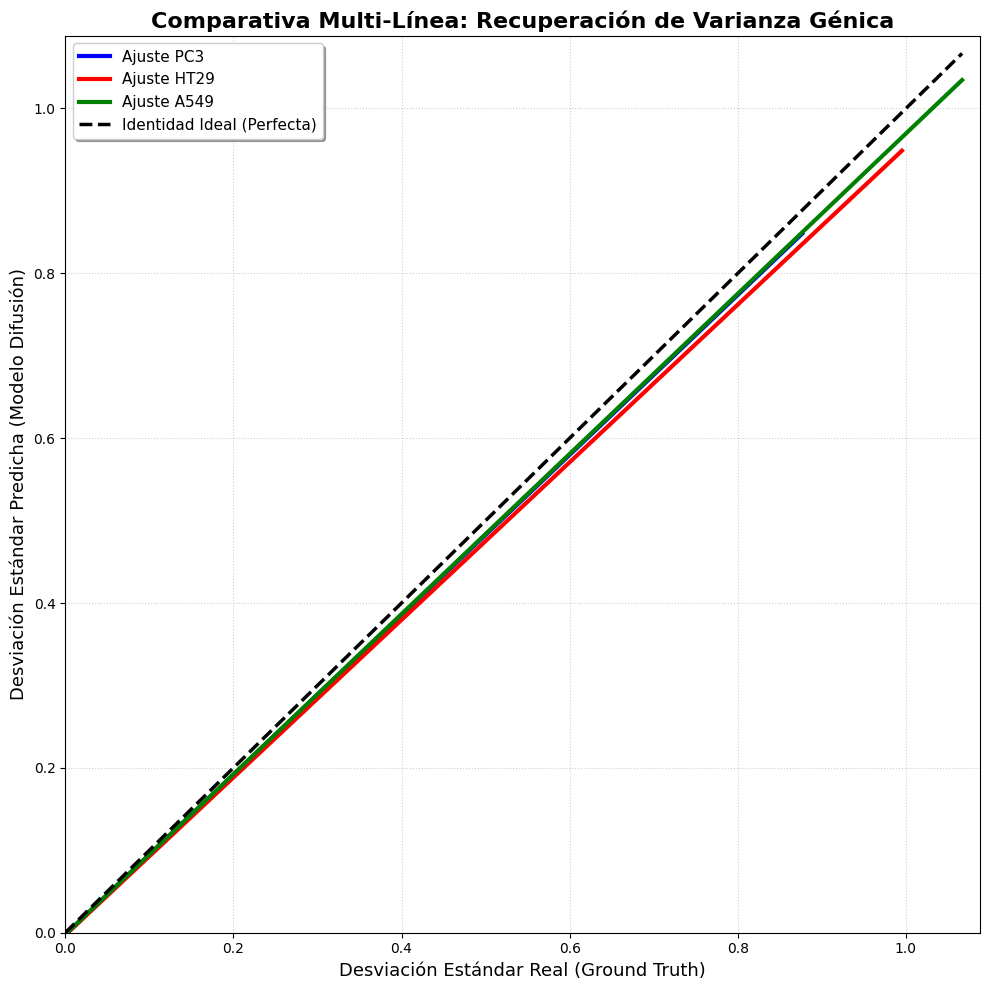

In [ ]:
plt.figure(figsize=(10, 10))

lineas = ["PC3", "HT29", "A549"]
colores = ['blue', 'red', 'green']


for i, nombre in enumerate(lineas):
    if nombre not in resultados_por_linea:
        continue

    y_real = resultados_por_linea[nombre]['true']
    y_pred = resultados_por_linea[nombre]['pred']

    # Calculamos la varianza (std) por gen
    std_real = np.std(y_real, axis=0)
    std_pred = np.std(y_pred, axis=0)

    # Actualizamos el máximo para el eje
    max_global = max(0, np.max(std_real), np.max(std_pred))

    # Cálculo de la regresión
    slope, intercept, r_val, _, _ = linregress(std_real, std_pred)

    x_range = np.array([0, np.max(std_real)])
    plt.plot(x_range, slope * x_range + intercept, color=colores[i],
             linewidth=3, label=f'Ajuste {nombre}')

# Identidad
plt.plot([0, max_global], [0, max_global], color='black',
         linestyle='--', linewidth=2.5, label='Identidad Ideal (Perfecta)')

plt.title("Comparativa Multi-Línea: Recuperación de Varianza Génica", fontsize=16, fontweight='bold')
plt.xlabel("Desviación Estándar Real (Ground Truth)", fontsize=13)
plt.ylabel("Desviación Estándar Predicha (Modelo Difusión)", fontsize=13)

plt.xlim(0, max_global * 1.02)
plt.ylim(0, max_global * 1.02)
plt.grid(True, linestyle=':', alpha=0.6)

plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)

plt.tight_layout()
plt.show()